# Paso 2 — La verdad de referencia

Este cuaderno no busca nada todavía. Construye **la regla con la que se va a
juzgar** a los buscadores que vienen después.

Es el paso que casi todos los tutoriales se saltan, y por eso casi todos acaban
enseñando tres resultados bonitos escogidos a mano. Sin una verdad de referencia
no se puede decir «esto funciona»: solo se puede decir «esto me gustó».

## Lo que hay que dejar montado

1. **Arreglar las etiquetas** — hay categorías solapadas y una demasiado pequeña.
2. **Aislar el texto repetido** que el cuaderno anterior detectó, para poder medir
   con y sin él.
3. **Escribir las consultas**, sin usar el nombre del equipo ni palabras del
   título. Aquí está la parte delicada del proyecto.
4. **Implementar las métricas** y un **control aleatorio** que marque el suelo.
5. **Comprobar que las consultas no hacen trampa** antes de usarlas para nada.


In [1]:
import json
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESADO = RAIZ / "datos" / "procesado"
RESULTADOS = RAIZ / "resultados"
RESULTADOS.mkdir(exist_ok=True)

ACENTO = "#5E6AD2"
AVISO = "#e0803c"
GRIS = "#8A8F98"

SEMILLA = 42
pd.set_option("display.width", 180)

corpus = pd.read_parquet(PROCESADO / "corpus.parquet")
print(f"corpus: {len(corpus):,} ofertas")
print(corpus.groupby("fuente").size().to_string())

corpus: 10,145 ofertas
fuente
booking              819
business_analyst    3724
seek_au             5602


---

# 1. Arreglar las etiquetas

El cuaderno anterior dejó dos problemas apuntados en el campo `Team` de Booking.

In [2]:
equipos_crudos = corpus.loc[corpus["fuente"] == "booking", "etiqueta"].value_counts()
equipos_crudos

etiqueta
Engineering                       216
Business Development & Support    156
People                             94
Security & Infrastructure          61
Design & User Experience           48
Product                            47
Marketing & Communications         46
Data Science & Analytics           39
Customer Service                   38
Leadership                         27
Finance & Legal                    25
Finance                            10
IT Services                         7
Legal & Public Affairs              5
Name: count, dtype: int64

### Problema 1: tres categorías para lo mismo

`Finance & Legal`, `Finance` y `Legal & Public Affairs` coexisten porque la
taxonomía de Booking cambió entre las tres capturas. La misma oferta puede estar
en una u otra según la fecha en que se recogió.

Dejarlas separadas penalizaría al buscador por un error que no es suyo: si
recupera una oferta de `Finance` cuando la consulta apuntaba a `Finance & Legal`,
se contaría como fallo aunque sea exactamente lo que se buscaba.

**Se fusionan en una sola categoría.**

In [3]:
FUSION = {
    "Finance": "Finance & Legal",
    "Legal & Public Affairs": "Finance & Legal",
}

booking = corpus[corpus["fuente"] == "booking"].copy()
booking["equipo"] = booking["etiqueta"].replace(FUSION)

equipos = booking["equipo"].value_counts()
print(f"{len(equipos)} equipos tras fusionar:\n")
print(equipos.to_string())

12 equipos tras fusionar:

equipo
Engineering                       216
Business Development & Support    156
People                             94
Security & Infrastructure          61
Design & User Experience           48
Product                            47
Marketing & Communications         46
Finance & Legal                    40
Data Science & Analytics           39
Customer Service                   38
Leadership                         27
IT Services                         7


### Problema 2: una categoría demasiado pequeña

`IT Services` se queda en **7 ofertas**. Con siete documentos relevantes, una
sola posición acertada mueve la métrica un 14 %, así que cualquier diferencia
entre métodos quedaría enterrada bajo el ruido.

Es la misma situación que la clase `Worms` del proyecto anterior, con sus 41
ejemplos. Allí se reportó con la advertencia porque era **el objetivo del
proyecto**; aquí es solo una consulta de doce, y mantenerla distorsionaría el
promedio sin aportar nada.

> **Decisión: se excluye `IT Services` de la evaluación.** Sus 7 ofertas siguen
> en el índice —pueden y deben recuperarse por error, como cualquier otra— pero
> no se escribe una consulta para ellas.

Quedan **11 equipos**, el más pequeño con 27 ofertas.

In [4]:
MINIMO = 20
evaluables = equipos[equipos >= MINIMO]
excluidos = equipos[equipos < MINIMO]

print(f"Equipos evaluables ({len(evaluables)}): mínimo {evaluables.min()} ofertas")
print(f"Excluidos: {', '.join(f'{k} ({v})' for k, v in excluidos.items()) or 'ninguno'}")
print(f"\nOfertas relevantes en total: {evaluables.sum():,} "
      f"de {len(corpus):,} del corpus ({evaluables.sum()/len(corpus)*100:.1f}%)")

Equipos evaluables (11): mínimo 27 ofertas
Excluidos: IT Services (7)

Ofertas relevantes en total: 812 de 10,145 del corpus (8.0%)


---

# 2. Aislar el texto repetido

El cuaderno anterior midió que **más de la mitad de las ofertas de Booking empieza
igual que otra**, y que una de cada cuatro comparte 800 caracteres literales.
Ahora toca localizar ese texto para poder quitarlo.

**El método:** trocear cada oferta en párrafos y contar **en cuántas ofertas
distintas aparece cada párrafo**. Un párrafo que sale en el 2 % o más de las
ofertas de su fuente no describe ese puesto concreto — describe a la empresa.

Es el mismo razonamiento que las *stopwords*, pero a nivel de párrafo en lugar de
palabra: lo que aparece en todas partes no distingue nada.

In [5]:
def parrafos(texto):
    """Divide en párrafos no vacíos y los normaliza para poder compararlos."""
    return [re.sub(r"\s+", " ", p).strip().lower()
            for p in re.split(r"\n+", texto) if p.strip()]


def parrafos_repetidos(textos, umbral=0.02, minimo=3):
    """Devuelve los párrafos que aparecen en al menos `umbral` de los documentos."""
    frecuencia = Counter()
    for texto in textos:
        # set(): un párrafo repetido dentro del mismo documento cuenta una vez.
        for p in set(parrafos(texto)):
            frecuencia[p] += 1
    corte = max(minimo, len(textos) * umbral)
    return {p for p, n in frecuencia.items() if n >= corte}, frecuencia


# El cálculo se hace por fuente: cada una tiene sus propias plantillas.
repetidos_por_fuente = {}
resumen = []
for fuente in corpus["fuente"].unique():
    textos = corpus.loc[corpus["fuente"] == fuente, "descripcion"].tolist()
    repetidos, frecuencia = parrafos_repetidos(textos)
    repetidos_por_fuente[fuente] = repetidos
    resumen.append({
        "fuente": fuente,
        "ofertas": len(textos),
        "párrafos_distintos": len(frecuencia),
        "marcados_repetidos": len(repetidos),
    })

pd.DataFrame(resumen).set_index("fuente")

,ofertas,párrafos_distintos,marcados_repetidos
fuente,,,
seek_au,5602,5602,0
booking,819,14155,168
business_analyst,3724,66240,22


In [6]:
# Los párrafos más repetidos de Booking, que es donde estaba el problema.
_, frec_booking = parrafos_repetidos(
    corpus.loc[corpus["fuente"] == "booking", "descripcion"].tolist()
)
top = sorted(frec_booking.items(), key=lambda x: -x[1])[:8]
for texto, n in top:
    print(f"[{n:4} de 819 ofertas]  {texto[:95]}{'…' if len(texto) > 95 else ''}")

[ 388 de 819 ofertas]  b.skilled
[ 374 de 819 ofertas]  b.responsible
[ 319 de 819 ofertas]  b.offered
[ 275 de 819 ofertas]  booking.com is proud to be an equal opportunity workplace and is an affirmative action employer…
[ 125 de 819 ofertas]  competitive compensation and benefits package and some great added perks of working in the home…
[ 114 de 819 ofertas]  we are united in the belief that our very human desire to explore the planet’s beauty and disco…
[ 106 de 819 ofertas]  in fact, that’s what we do at booking.com. we make it easier for everyone to experience the wor…
[ 104 de 819 ofertas]  across our offices worldwide, we continue to innovate. to solve for some of the most complex ch…


### Qué se ve aquí

Los párrafos más repetidos de Booking son reveladores:

| Aparece en | Párrafo |
|---|---|
| 388 ofertas | `b.skilled` |
| 374 ofertas | `b.responsible` |
| 319 ofertas | `b.offered` |
| 275 ofertas | Aviso legal de igualdad de oportunidades |
| 125 ofertas | Descripción del paquete de beneficios |

Los tres primeros son **los títulos de sección de la plantilla interna de
Booking** — el equivalente a «Requisitos», «Responsabilidades» y «Qué ofrecemos»,
con la marca de la empresa pegada delante. No dicen absolutamente nada del puesto,
y aparecen en casi la mitad de las ofertas.

**Ese es exactamente el ruido que hace que una oferta de Ingeniería y otra de
Finanzas se parezcan** para un modelo de embeddings.

In [7]:
def limpiar(texto, fuente):
    """Quita los párrafos marcados como repetidos, conservando el texto original.

    La comparación se hace sobre la forma normalizada, pero lo que se devuelve es
    el párrafo tal cual venía: normalizar sirve para identificar, no para
    reescribir el corpus.
    """
    repetidos = repetidos_por_fuente[fuente]
    quedan = []
    for p in re.split(r"\n+", texto):
        if not p.strip():
            continue
        if re.sub(r"\s+", " ", p).strip().lower() not in repetidos:
            quedan.append(p.strip())
    return "\n".join(quedan)


corpus["texto_limpio"] = [
    limpiar(t, f) for t, f in zip(corpus["descripcion"], corpus["fuente"])
]
corpus["car_original"] = corpus["descripcion"].str.len()
corpus["car_limpio"] = corpus["texto_limpio"].str.len()

efecto = corpus.groupby("fuente").agg(
    car_original=("car_original", "sum"),
    car_limpio=("car_limpio", "sum"),
)
efecto["% eliminado"] = (
    (1 - efecto["car_limpio"] / efecto["car_original"]) * 100
).round(1)
efecto["ofertas_vacías"] = corpus[corpus["car_limpio"] == 0].groupby("fuente").size()
efecto = efecto.fillna(0)
efecto

,car_original,car_limpio,% eliminado,ofertas_vacías
fuente,,,,
booking,4027897,3195827,20.7,0.0
business_analyst,11578179,11493536,0.7,0.0
seek_au,16496442,16496241,0.0,0.0


### Qué se ve aquí — y un aviso importante

**En Booking se elimina el 20,7 % del texto.** Una quinta parte de esas ofertas
era plantilla corporativa. Ninguna oferta se queda vacía, así que la limpieza no
destruye nada.

En Business Analyst el efecto es mínimo y en **Seek es exactamente cero**.

Ese cero merece explicación, porque **no significa que Seek esté limpia**. El
cuaderno anterior midió que el 18 % de sus ofertas comparte los primeros 100
caracteres. Lo que pasa es que **las descripciones de Seek vienen en un solo
bloque, sin saltos de línea**, así que trocear por párrafos devuelve un único
párrafo por oferta y el método no tiene nada que agrupar.

> **Limitación declarada:** el método detecta plantillas *estructuradas por
> párrafos*. La repetición de Seek es de otro tipo —un mismo anunciante
> publicando ofertas casi idénticas— y no la captura.
>
> Se acepta porque **Seek solo aporta distractores**, no ofertas relevantes: su
> repetición no contamina la verdad de referencia. Si más adelante se quisiera
> evaluar sobre Seek, habría que resolverlo antes.

---

# 3. Las consultas

Aquí está la decisión más delicada del proyecto, y conviene explicar el
procedimiento antes de enseñar el resultado — porque **el procedimiento es lo que
hace que las cifras signifiquen algo**.

### Las reglas que me impuse

1. **No usar el nombre del equipo.** Una consulta para `Design & User Experience`
   no puede contener «design» ni «user experience». Si lo hiciera, estaría
   midiendo coincidencia de cadenas, que es justo lo que la búsqueda semántica
   dice superar.
2. **No usar palabras del título** de los puestos.
3. **Escribirlas mirando solo el nombre del equipo**, sin leer las ofertas. Si las
   redacto después de ver qué palabras usan las ofertas relevantes, las estaría
   ajustando a la respuesta.
4. **En inglés**, como el corpus.

### Por qué en inglés, y no en español

Es tentador escribir las consultas en español: la demo queda más vistosa y
encaja con la promesa de «buscar con mis palabras». **Pero sería hacer trampa.**

BM25 compara palabras. Con consultas en español contra ofertas en inglés, BM25
sacaría cero por construcción, y la búsqueda semántica ganaría por goleada sin
haber demostrado nada — solo que el modelo es multilingüe y BM25 no.

**La comparación tiene que ser justa para que la conclusión valga.** La búsqueda
en español queda como demostración final en el paso 7, etiquetada como lo que es:
una capacidad extra del modelo, no el resultado del experimento.

### La limitación que hay que declarar

**Las escribí yo.** Aunque no mirara las ofertas, conozco el dominio y eso
inevitablemente influye. Una consulta mal redactada puede hundir a un equipo y
no habría forma de distinguirlo de un fallo del buscador.

Lo que sí se puede hacer, y se hace más abajo, es **comprobar que no hay fuga
léxica**: que las palabras de la consulta no aparezcan casi en exclusiva en las
ofertas relevantes.

In [8]:
# Redactadas a partir del nombre del equipo, sin leer las ofertas y sin usar
# ninguna palabra del propio nombre.
CONSULTAS = {
    "Engineering":
        "writing and maintaining the code behind a website that millions of "
        "people use every day",
    "Business Development & Support":
        "negotiating agreements with partner companies and helping them increase "
        "their sales",
    "People":
        "hiring new colleagues, helping them settle in and looking after their "
        "careers and wellbeing",
    "Security & Infrastructure":
        "protecting company systems from intruders and keeping servers and "
        "networks available",
    "Design & User Experience":
        "shaping how a product looks and feels, running research with the people "
        "who use it and building prototypes",
    "Product":
        "deciding what should be built next and why, balancing what customers "
        "need with what the business needs",
    "Marketing & Communications":
        "planning campaigns to reach new audiences and managing how the brand "
        "speaks in public",
    "Finance & Legal":
        "handling budgets, taxes and contracts, and making sure the company "
        "follows regulations",
    "Data Science & Analytics":
        "turning raw numbers into insight, building statistical models and "
        "measuring whether a change actually worked",
    "Customer Service":
        "answering questions and fixing problems for customers by phone, email "
        "and chat",
    "Leadership":
        "leading several teams at once, setting direction and being accountable "
        "for results across a whole department",
}

consultas = pd.DataFrame({
    "equipo": list(CONSULTAS),
    "consulta": list(CONSULTAS.values()),
})
consultas["relevantes"] = consultas["equipo"].map(equipos)
consultas

,equipo,consulta,relevantes
0,Engineering,writing and maintaining the code behind a webs...,216
1,Business Development & Support,negotiating agreements with partner companies ...,156
2,People,"hiring new colleagues, helping them settle in ...",94
3,Security & Infrastructure,protecting company systems from intruders and ...,61
4,Design & User Experience,"shaping how a product looks and feels, running...",48
5,Product,"deciding what should be built next and why, ba...",47
6,Marketing & Communications,planning campaigns to reach new audiences and ...,46
7,Finance & Legal,"handling budgets, taxes and contracts, and mak...",40
8,Data Science & Analytics,"turning raw numbers into insight, building sta...",39
9,Customer Service,answering questions and fixing problems for cu...,38


---

# 4. La verdad de referencia

Una oferta es **relevante** para una consulta si pertenece al equipo que esa
consulta describe. Nada más.

El resto del corpus —las 9 300 ofertas de Seek y Business Analyst, más los otros
equipos de Booking— son **distractores**: están en el índice y pueden recuperarse
por error. Eso es lo que hace la evaluación realista.

In [9]:
# Se asigna a cada oferta del corpus su equipo, o None si no es de Booking.
corpus["equipo"] = None
corpus.loc[booking.index, "equipo"] = booking["equipo"]

# relevantes[equipo] = conjunto de ids de las ofertas de ese equipo.
relevantes = {
    equipo: set(corpus.loc[corpus["equipo"] == equipo, "id"])
    for equipo in consultas["equipo"]
}

print(f"Corpus indexado:      {len(corpus):,} ofertas")
print(f"Con equipo asignado:  {corpus['equipo'].notna().sum():,}")
print(f"Distractores:         {corpus['equipo'].isna().sum():,} "
      f"({corpus['equipo'].isna().mean()*100:.1f}%)\n")
for equipo, ids in relevantes.items():
    print(f"  {equipo:32} {len(ids):4} relevantes")

Corpus indexado:      10,145 ofertas
Con equipo asignado:  819
Distractores:         9,326 (91.9%)

  Engineering                       216 relevantes
  Business Development & Support    156 relevantes
  People                             94 relevantes
  Security & Infrastructure          61 relevantes
  Design & User Experience           48 relevantes
  Product                            47 relevantes
  Marketing & Communications         46 relevantes
  Finance & Legal                    40 relevantes
  Data Science & Analytics           39 relevantes
  Customer Service                   38 relevantes
  Leadership                         27 relevantes


---

# 5. Las métricas

En el plan inicial la métrica principal iba a ser **Recall@10**. Al tener los
números delante hay que cambiarla, y el motivo es instructivo.

`Engineering` tiene **216 ofertas relevantes**. Si solo se miran los 10 primeros
resultados, el recall máximo alcanzable es 10/216 = **0,046**. Un buscador
perfecto sacaría un 4,6 % y parecería pésimo.

Peor aún: el techo es distinto para cada consulta —`Leadership` con 27 relevantes
podría llegar a 0,37— así que **las consultas no serían comparables entre sí**.

> **Decisión: la métrica principal es `Precision@10`** — de los 10 resultados
> devueltos, cuántos son del equipo correcto. Su techo es 1,0 para todas las
> consultas, así que sí son comparables.

Se acompañan de:

| Métrica | Qué añade |
|---|---|
| **MRR** | En qué posición aparece el **primer** acierto |
| **nDCG@10** | Si los aciertos están arriba o abajo dentro del top 10 |
| **Recall@100** | Si el buscador encuentra el grupo, aunque no lo ordene bien |

In [10]:
def precision_en_k(ranking, ids_relevantes, k=10):
    """Proporción de los k primeros resultados que son relevantes."""
    return sum(1 for i in ranking[:k] if i in ids_relevantes) / k


def recall_en_k(ranking, ids_relevantes, k=100):
    """Proporción de las ofertas relevantes que aparecen en los k primeros."""
    if not ids_relevantes:
        return 0.0
    return sum(1 for i in ranking[:k] if i in ids_relevantes) / len(ids_relevantes)


def rr(ranking, ids_relevantes):
    """Inverso de la posición del primer acierto. 0 si no hay ninguno."""
    for posicion, i in enumerate(ranking, start=1):
        if i in ids_relevantes:
            return 1 / posicion
    return 0.0


def ndcg_en_k(ranking, ids_relevantes, k=10):
    """Calidad del orden: premia los aciertos cuanto más arriba estén."""
    ganancia = sum(
        1 / np.log2(posicion + 1)
        for posicion, i in enumerate(ranking[:k], start=1)
        if i in ids_relevantes
    )
    # El máximo posible: todos los aciertos en las primeras posiciones.
    ideal = sum(1 / np.log2(p + 1) for p in range(1, min(k, len(ids_relevantes)) + 1))
    return ganancia / ideal if ideal else 0.0


def evaluar(rankings, nombre):
    """Aplica las cuatro métricas a un ranking por consulta y promedia."""
    filas = []
    for equipo, ranking in rankings.items():
        ids = relevantes[equipo]
        filas.append({
            "equipo": equipo,
            "relevantes": len(ids),
            "P@10": precision_en_k(ranking, ids),
            "MRR": rr(ranking, ids),
            "nDCG@10": ndcg_en_k(ranking, ids),
            "R@100": recall_en_k(ranking, ids),
        })
    detalle = pd.DataFrame(filas).set_index("equipo")
    detalle.attrs["nombre"] = nombre
    return detalle


print("Métricas listas.")

Métricas listas.


---

# 6. El control aleatorio

Es el equivalente del `DummyClassifier` del proyecto anterior: un «buscador» que
devuelve resultados al azar, ignorando la consulta.

Su puntuación es **el suelo**. Cualquier método que no lo supere con claridad no
está aportando nada, por muy sofisticado que sea.

Se repite con varias semillas, porque una sola tirada de dados no es una medida.

In [11]:
ids_corpus = corpus["id"].to_numpy()

def buscador_aleatorio(semilla):
    """Devuelve un orden al azar, el mismo para todas las consultas."""
    rng = np.random.default_rng(semilla)
    orden = rng.permutation(ids_corpus)
    return {equipo: orden for equipo in consultas["equipo"]}


# 50 tiradas: con 10 la media todavía se movía bastante entre ejecuciones.
TIRADAS = 50
repeticiones = [evaluar(buscador_aleatorio(s), f"aleatorio {s}") for s in range(TIRADAS)]
aleatorio = sum(r[["P@10", "MRR", "nDCG@10", "R@100"]] for r in repeticiones) / TIRADAS
aleatorio["relevantes"] = consultas.set_index("equipo")["relevantes"]

print(f"Media de {TIRADAS} tiradas:\n")
print(aleatorio.round(4).to_string())
print("\nPromedio sobre las 11 consultas:")
print(aleatorio[["P@10", "MRR", "nDCG@10", "R@100"]].mean().round(4).to_string())

Media de 50 tiradas:

                                 P@10     MRR  nDCG@10   R@100  relevantes
equipo                                                                    
Engineering                     0.016  0.0731   0.0164  0.0109         216
Business Development & Support  0.012  0.0500   0.0108  0.0096         156
People                          0.006  0.0413   0.0074  0.0100          94
Security & Infrastructure       0.012  0.0745   0.0166  0.0111          61
Design & User Experience        0.008  0.0436   0.0093  0.0108          48
Product                         0.004  0.0141   0.0029  0.0064          47
Marketing & Communications      0.008  0.0383   0.0085  0.0109          46
Finance & Legal                 0.002  0.0160   0.0015  0.0120          40
Data Science & Analytics        0.002  0.0117   0.0013  0.0097          39
Customer Service                0.006  0.0226   0.0050  0.0121          38
Leadership                      0.002  0.0178   0.0028  0.0089          27

Pr

### Qué se ve aquí

El suelo está **muy abajo**, y era de esperar: hay 10 145 ofertas y como mucho 216
son relevantes para una consulta dada.

Ese número tan pequeño es una buena noticia para la evaluación. Significa que
**acertar por azar es prácticamente imposible**, así que cualquier resultado
apreciable que salga después es señal, no ruido.

Compárese con el proyecto anterior, donde el modelo tonto sacaba 0,648 de accuracy
y había que explicar por qué eso no valía nada. Aquí el problema contrario no
existe: el suelo es casi cero.

---

# 7. ¿Hacen trampa las consultas?

Antes de usar esta verdad de referencia para juzgar a nadie, hay que auditarla.

**El riesgo concreto:** que las palabras que escribí aparezcan casi en exclusiva
en las ofertas del equipo correcto. Si la consulta de `Engineering` contiene
«code» y resulta que «code» sale solo en las ofertas de ingeniería, entonces
cualquier buscador por palabras clave acertaría sin entender nada — y yo habría
construido la respuesta dentro de la pregunta.

Se mide con el **cociente de elevación**: cuántas veces más frecuente es una
palabra de la consulta en las ofertas relevantes frente al resto del corpus.

In [12]:
def palabras(texto):
    """Palabras de cuatro letras o más, en minúsculas."""
    return {p for p in re.findall(r"[a-z]{4,}", texto.lower())}


# Vocabulario de cada oferta, calculado una sola vez.
vocabulario = [palabras(t) for t in corpus["texto_limpio"]]
indice_por_id = {i: pos for pos, i in enumerate(corpus["id"])}

filas = []
for equipo, consulta in CONSULTAS.items():
    ids = relevantes[equipo]
    posiciones_rel = [indice_por_id[i] for i in ids]
    posiciones_no = [p for p in range(len(corpus)) if p not in set(posiciones_rel)]

    elevaciones = []
    for palabra in palabras(consulta):
        en_rel = sum(1 for p in posiciones_rel if palabra in vocabulario[p]) / len(posiciones_rel)
        en_no = sum(1 for p in posiciones_no if palabra in vocabulario[p]) / len(posiciones_no)
        if en_rel > 0 or en_no > 0:
            elevaciones.append((palabra, en_rel, en_no, en_rel / max(en_no, 1e-6)))

    elevaciones.sort(key=lambda x: -x[3])
    palabra, en_rel, en_no, elev = elevaciones[0]
    filas.append({
        "equipo": equipo,
        "palabras_consulta": len(elevaciones),
        "palabra_más_delatora": palabra,
        "% en relevantes": round(en_rel * 100, 1),
        "% en el resto": round(en_no * 100, 1),
        "elevación": round(elev, 1),
    })

fuga = pd.DataFrame(filas).set_index("equipo").sort_values("elevación", ascending=False)
fuga

,palabras_consulta,palabra_más_delatora,% en relevantes,% en el resto,elevación
equipo,,,,,
Data Science & Analytics,12,turning,15.4,0.3,47.1
Finance & Legal,9,taxes,5.0,0.2,29.7
Marketing & Communications,8,campaigns,43.5,1.7,26.1
Engineering,9,millions,49.5,2.5,19.5
Leadership,12,accountable,48.1,2.9,16.5
Customer Service,8,chat,18.4,1.2,15.3
Security & Infrastructure,8,servers,16.4,1.1,14.5
Design & User Experience,10,prototypes,10.4,0.8,12.5
People,10,hiring,40.4,3.6,11.1


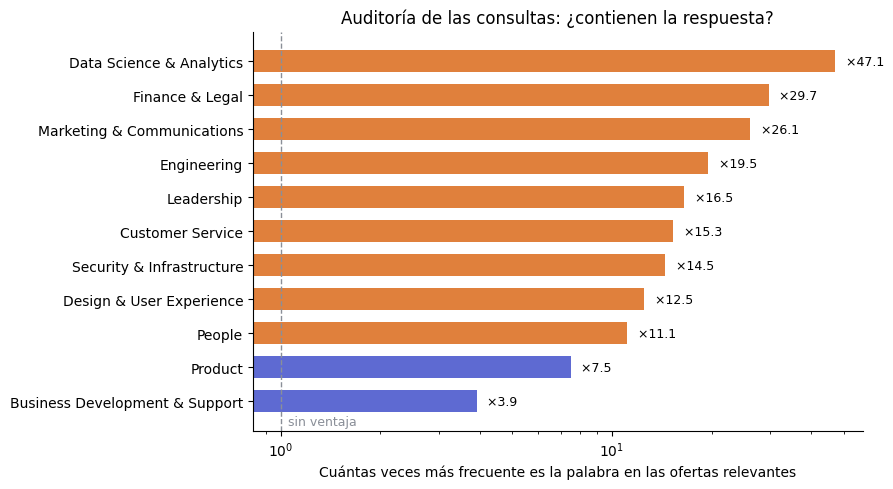

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
datos = fuga.sort_values("elevación")
colores = [AVISO if v >= 10 else ACENTO for v in datos["elevación"]]
barras = ax.barh(datos.index, datos["elevación"], color=colores, height=0.66)

ax.axvline(1, color=GRIS, linestyle="--", linewidth=1)
ax.text(1.05, -0.7, "sin ventaja", fontsize=9, color=GRIS)

ax.bar_label(barras, labels=[f"  ×{v:.1f}" for v in datos["elevación"]],
             padding=2, fontsize=9)
ax.set_xscale("log")
ax.set_xlabel("Cuántas veces más frecuente es la palabra en las ofertas relevantes")
ax.set_title("Auditoría de las consultas: ¿contienen la respuesta?")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
fig.savefig(RESULTADOS / "fuga-lexica.png", dpi=140)
plt.show()

### Qué se ve aquí — la auditoría no sale limpia, y eso está bien

Todas las consultas contienen alguna palabra claramente más frecuente en las
ofertas relevantes:

| Consulta | Palabra | En relevantes | En el resto | Elevación |
|---|---|---|---|---|
| Data Science & Analytics | `turning` | 15,4 % | 0,3 % | **×47** |
| Finance & Legal | `taxes` | 5,0 % | 0,2 % | ×30 |
| Marketing & Communications | `campaigns` | 43,5 % | 1,7 % | ×26 |
| Engineering | `millions` | 49,5 % | 2,5 % | ×20 |
| Leadership | `accountable` | 48,1 % | 2,9 % | ×17 |
| … | | | | |
| Business Development & Support | `negotiating` | 3,2 % | 0,8 % | ×3,9 |

Mi primera reacción al ver esto fue que las consultas estaban mal y había que
reescribirlas. **Es justo la conclusión equivocada**, y conviene explicar por qué.

**Qué significa en realidad.** Esta medición no detecta trampa: detecta que las
consultas están **escritas en el mismo idioma que el dominio**. Una oferta de
ingeniería de una web grande habla de escala; una de analítica habla de convertir
datos en algo útil. Que `millions` aparezca en la mitad de las ofertas de
`Engineering` es una propiedad del dominio, no un truco mío.

**Y lo importante: esto favorece a BM25, no a los embeddings.** BM25 solo puede
funcionar si hay coincidencia de palabras. Si yo hubiera eliminado toda señal
léxica —escribiendo consultas deliberadamente alejadas del vocabulario real—
habría **saboteado la línea base** y cualquier victoria posterior de la búsqueda
semántica sería falsa.

> **Lo que esta auditoría demuestra:** la comparación no está amañada **contra**
> BM25. Tiene anclas léxicas reales en las once consultas. Si aun así la búsqueda
> semántica gana, el resultado valdrá algo.

**Lo que sigue sin poder descartarse:** que yo eligiera esas palabras justamente
*porque* sé que aparecen. No puedo demostrar que no, y por eso queda escrito aquí
en lugar de omitido. La única defensa real sería que otra persona redactara las
consultas sin ver los datos.

---

# 8. Guardado

In [14]:
salida = corpus[[
    "id", "fuente", "titulo", "descripcion", "texto_limpio",
    "empresa", "ubicacion", "equipo", "car_original", "car_limpio",
]].copy()
salida.to_parquet(PROCESADO / "corpus_preparado.parquet", index=False)

consultas_salida = consultas.copy()
consultas_salida["ids_relevantes"] = consultas_salida["equipo"].map(
    lambda e: sorted(relevantes[e])
)
consultas_salida.to_parquet(PROCESADO / "consultas.parquet", index=False)

print(f"corpus_preparado.parquet: {len(salida):,} ofertas")
print(f"consultas.parquet:        {len(consultas_salida)} consultas")
print(f"\nSuelo aleatorio (P@10 promedio): "
      f"{aleatorio['P@10'].mean():.4f}")

corpus_preparado.parquet: 10,145 ofertas
consultas.parquet:        11 consultas

Suelo aleatorio (P@10 promedio): 0.0071


---

# Resumen

## Lo que queda montado

| Pieza | Estado |
|---|---|
| Corpus indexable | **10 145 ofertas**, con y sin texto repetido |
| Consultas | **11**, una por equipo |
| Ofertas relevantes | 812 de 10 145 (8,0 %) |
| Métricas | P@10, MRR, nDCG@10, R@100 |
| Suelo | Control aleatorio, media de 50 tiradas: **P@10 = 0,007** |

## Las decisiones y su porqué

1. **Fusionar `Finance`, `Legal & Public Affairs` y `Finance & Legal`.** La
   taxonomía cambió entre capturas; mantenerlas separadas penalizaría al buscador
   por un error que no es suyo.

2. **Excluir `IT Services`** (7 ofertas). Con siete relevantes, una posición
   mueve la métrica un 14 %. Siguen en el índice como distractores.

3. **Quitar los párrafos que aparecen en el 2 % o más de las ofertas de su
   fuente.** En Booking eso elimina el 20,7 % del texto — incluidas `b.skilled`,
   `b.responsible` y `b.offered`, que son los títulos de sección de su plantilla
   interna y aparecen en casi la mitad de las ofertas.

4. **Consultas en inglés, no en español.** Con consultas en español contra
   ofertas en inglés, BM25 sacaría cero por construcción y la comparación no
   demostraría nada. La búsqueda en español queda como demostración final,
   etiquetada como capacidad extra y no como resultado.

5. **`Precision@10` en lugar de `Recall@10`.** Con 216 ofertas relevantes, el
   recall máximo en 10 resultados es 0,046: un buscador perfecto parecería
   pésimo, y cada consulta tendría un techo distinto.

## Lo que queda declarado como limitación

- **Las consultas las escribí yo.** Aunque siguiera reglas —no usar el nombre del
  equipo, no leer las ofertas antes— conozco el dominio y eso influye. La
  auditoría mostró que **todas las consultas contienen alguna palabra hasta 47
  veces más frecuente en las ofertas relevantes**. Eso no invalida la comparación
  —de hecho favorece a BM25, que es la línea base— pero **no puedo demostrar que
  no elegí esas palabras porque sé que aparecen**. La única defensa real sería que
  otra persona redactara las consultas sin ver los datos.
- **El detector de plantillas no funciona en Seek**, porque sus descripciones
  vienen sin saltos de línea. Se acepta porque Seek solo aporta distractores.
- **Un equipo no es un puesto.** Una oferta de `Product` puede ser legítimamente
  relevante para la consulta de `Engineering`, y se contará como fallo. Afecta por
  igual a todos los métodos comparados.

## Siguiente paso

Con la regla montada, ya se puede juzgar. El paso 3 trae **BM25**, la búsqueda
clásica por palabras clave — y conviene no subestimarla: es la línea base que
lleva décadas siendo difícil de batir.
